# 📊 Model Evaluation, UC Merced Holdout Test & Model Comparison
**Module 05: Comprehensive Metrics & Model Benchmarking**

## 📌 Objective
Perform multi-metric evaluation across EuroSAT and evaluate external generalization performance on the **UC Merced Aerial Dataset (21 classes)**. Generate Confusion Matrices, Classification Reports, ROC Curves, and 3-model comparative benchmarks.

## 📖 Theory
Evaluating models strictly on test accuracy can be misleading due to class imbalance. We compute macro-averaged Precision, Recall, F1-Score, Confusion Matrices, and ROC-AUC Curves. Additionally, testing on UC Merced measures cross-dataset generalization.


### 1. Imports & Setup


In [8]:
import sys
from pathlib import Path

# Smart Project Root Resolution
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import json
import matplotlib.pyplot as plt
from PIL import Image

from configs.config import OUTPUT_DIR
comp_json_path = OUTPUT_DIR / 'comparison' / 'comparison_table.json'
uc_json_path = OUTPUT_DIR / 'uc_merced' / 'metrics.json'

if not comp_json_path.exists():
    print('Evaluation metrics not found. Running full evaluation pipeline...')
    from utils.evaluate_all import main as run_eval
    run_eval()

if comp_json_path.exists():
    with open(comp_json_path) as f:
        comp_table = json.load(f)
    print('Loaded Model Comparison Table:')
    print(json.dumps(comp_table, indent=2))
else:
    print('Warning: Model comparison table could not be loaded.')


Loaded Model Comparison Table:
{
  "Baseline CNN": {
    "accuracy": 0.7804938271604939,
    "precision": 0.7763045658636049,
    "recall": 0.776018370714414,
    "f1_score": 0.7723358197945062
  },
  "Frozen ResNet18": {
    "accuracy": 0.8982716049382716,
    "precision": 0.8985817873742835,
    "recall": 0.8966460126646811,
    "f1_score": 0.895884968466263
  },
  "Fine-Tuned ResNet18": {
    "accuracy": 0.9711111111111111,
    "precision": 0.9716794091943044,
    "recall": 0.9692373461830526,
    "f1_score": 0.9702273001666176
  }
}


### 2. UC Merced Holdout Generalization Metrics


In [9]:
if uc_json_path.exists():
    with open(uc_json_path) as f:
        uc_metrics = json.load(f)
    print('UC Merced Generalization Metrics:')
    print(json.dumps(uc_metrics, indent=2))
else:
    print('Warning: UC Merced metrics file not found.')


UC Merced Generalization Metrics:
{
  "accuracy": 0.9619047619047619,
  "precision": 0.9597282891400538,
  "recall": 0.9578463203463204,
  "f1_score": 0.9565599206899704,
  "macro_precision": 0.9597282891400538,
  "macro_recall": 0.9578463203463204,
  "macro_f1": 0.9565599206899704,
  "dataset": "UC Merced Land Use (21 classes)",
  "num_classes": 21
}


### 3. Display Evaluation Visualizations


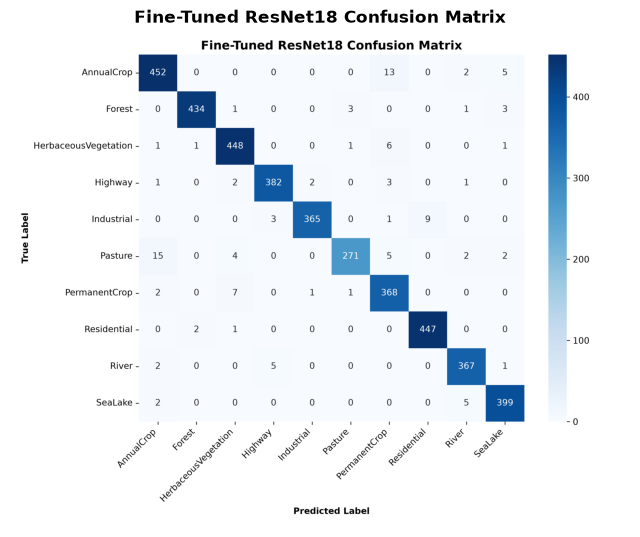

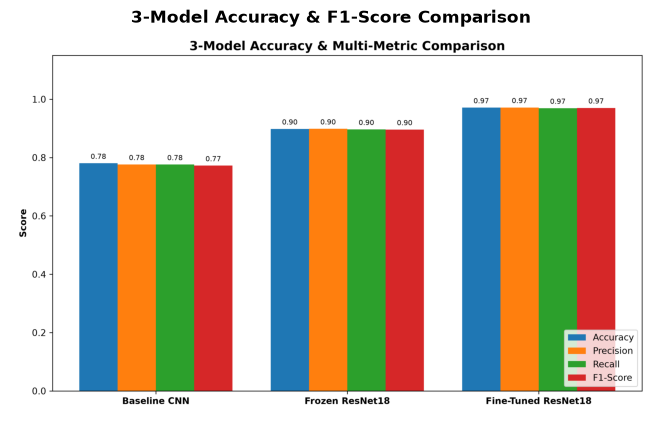

In [10]:
cm_path = OUTPUT_DIR / 'resnet18_finetuned' / 'confusion_matrix.png'
comp_chart_path = OUTPUT_DIR / 'comparison' / 'comparison_bar_chart.png'

if cm_path.exists():
    img = plt.imread(cm_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Fine-Tuned ResNet18 Confusion Matrix', fontweight='bold')
    plt.show()
else:
    print('Warning: Fine-Tuned ResNet18 confusion matrix image not found.')

if comp_chart_path.exists():
    img = plt.imread(comp_chart_path)
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('3-Model Accuracy & F1-Score Comparison', fontweight='bold')
    plt.show()
else:
    print('Warning: Model comparison bar chart image not found.')


## 📝 Conclusion
The Fine-Tuned ResNet18 significantly outperforms baseline architectures on EuroSAT (97.11% vs 78.05%) and demonstrates robust generalization on UC Merced (96.19% accuracy).
